## 1. Imports

In [2]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings

from flow_tree_utils import OBJECTS,collapse_traj, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_traj_from_path, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [3]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
test_df["accuracy"] = test_df["accuracy"].astype(bool)


## 3. Make node Flow Trees

### Start-node Flow Trees

In [4]:
## BY START
# All trajectories
start_tree_dict = {}
for start_node, group in test_df.groupby(["StartAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    start_tree_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

# Winners only
start_winner_dict = {}
for start_node, group in test_df[test_df["accuracy"]].groupby(["StartAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
    start_winner_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

# Losers only  
start_loser_dict = {}
for start_node, group in test_df[~test_df["accuracy"]].groupby(["StartAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
    start_loser_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

### Plot Start-node Flow Trees

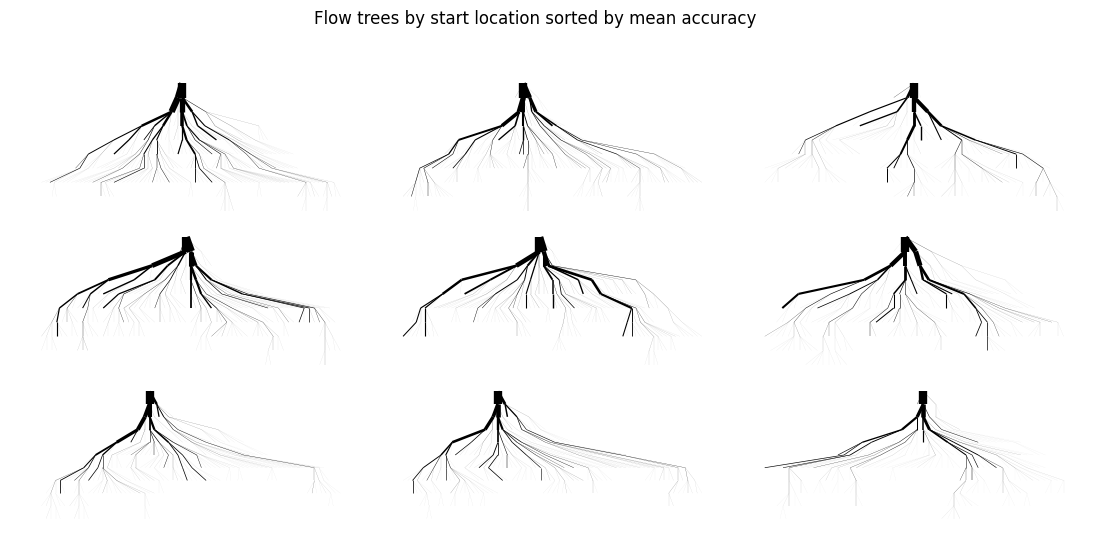

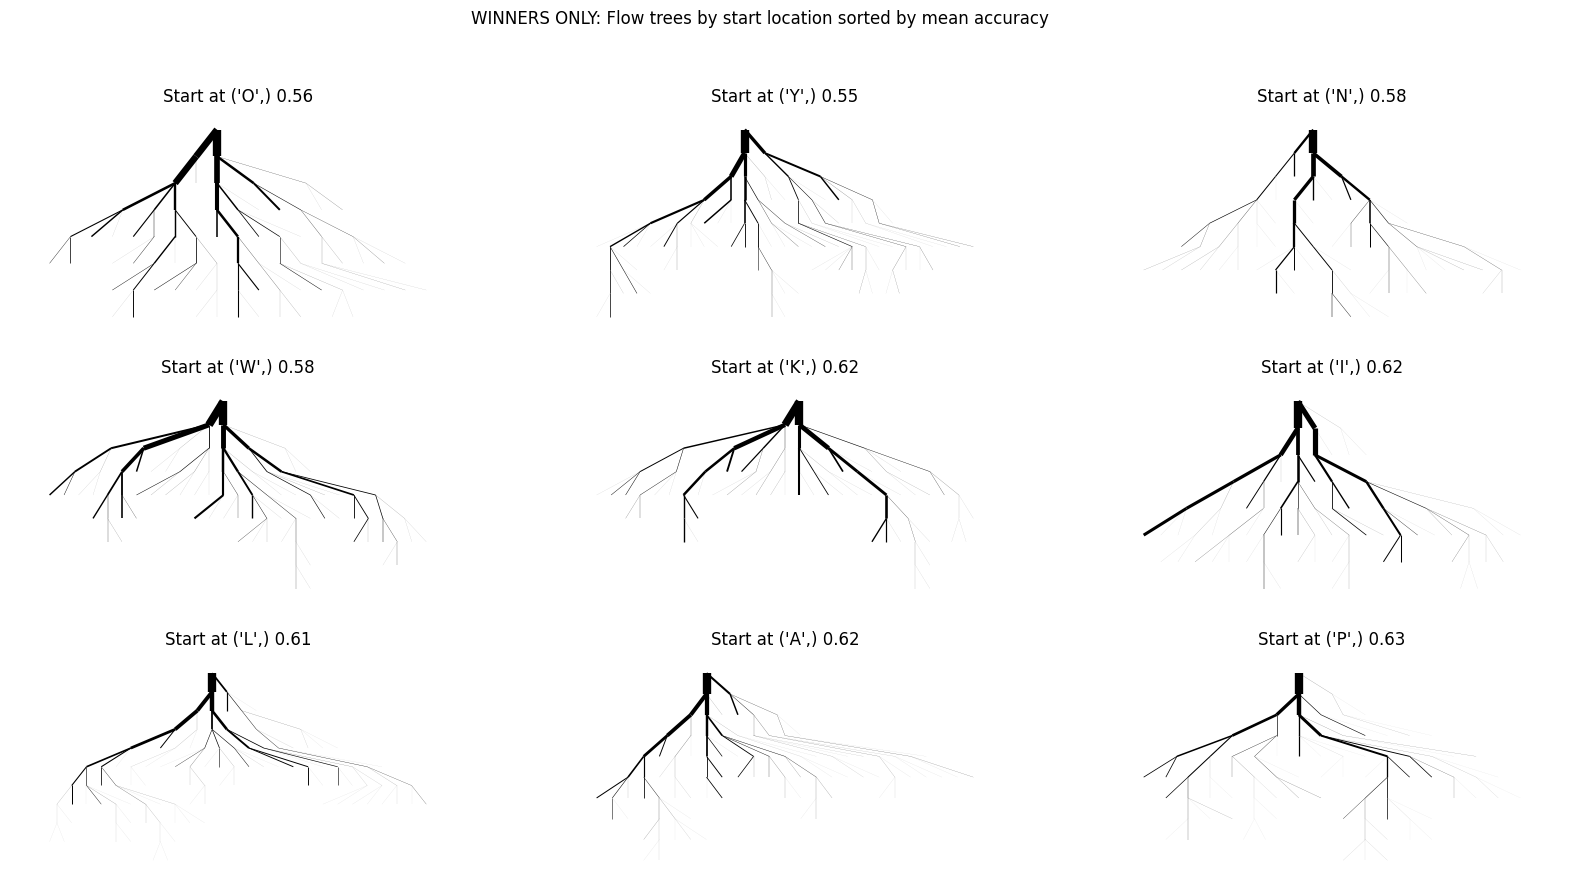

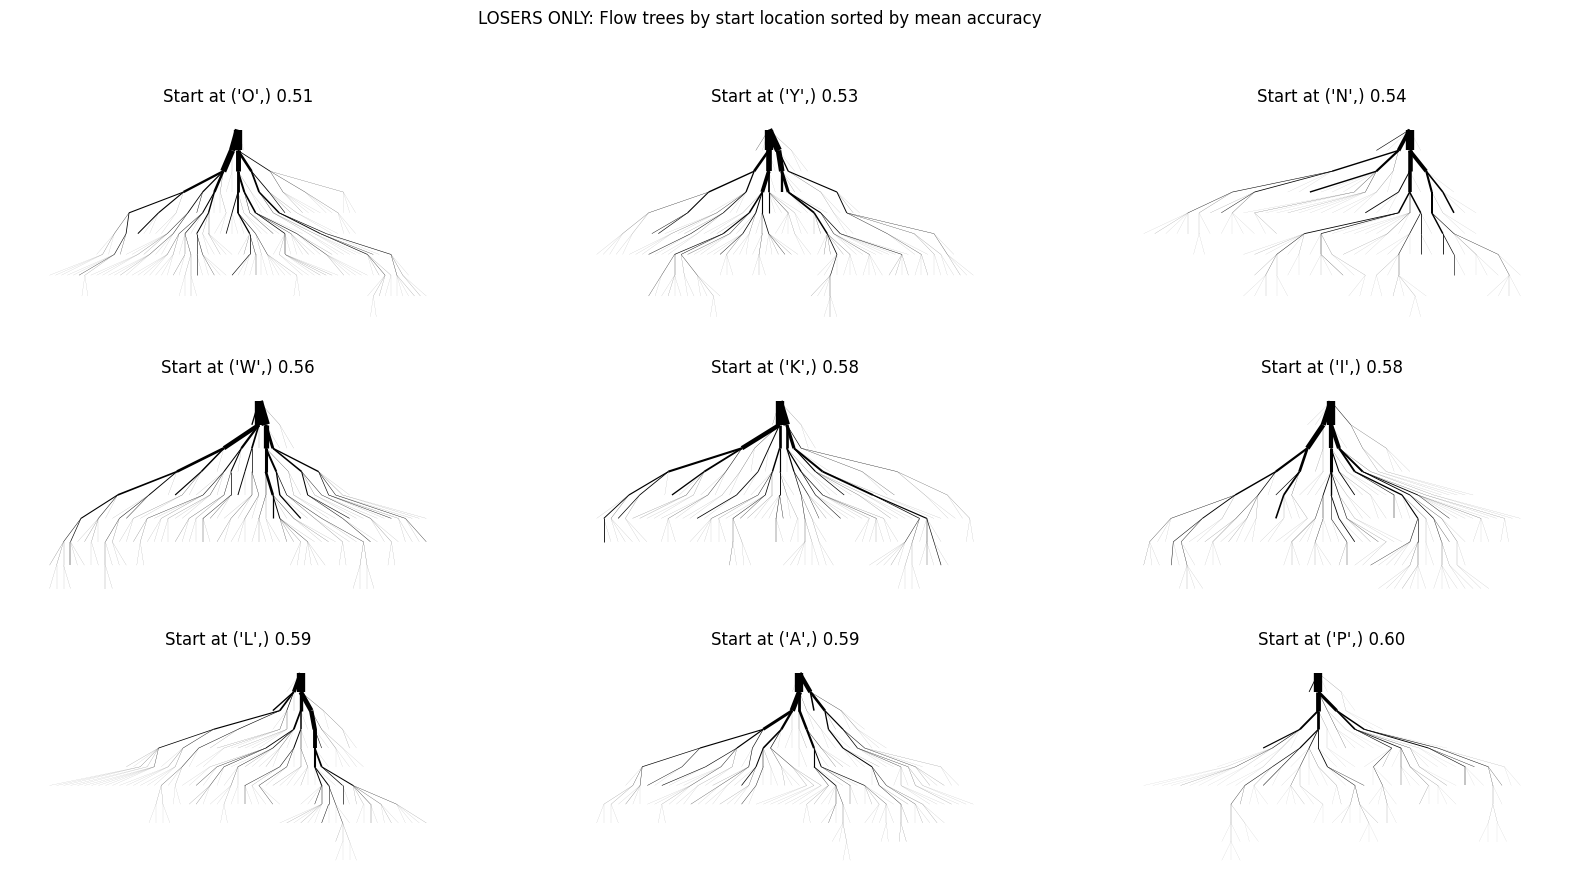

In [5]:
# Plot all trajectories
start_accs = [v[1] for v in start_tree_dict.values()]
start_graphs = [v[0] for v in start_tree_dict.values()]
start_nodes = list(start_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(14,6))
plt.subplots_adjust(wspace=0, hspace=0)  # Remove spacing between subplots
sorted_order = [x for x in sorted(range(len(start_accs)), key=lambda x: start_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, "", ax, just_edges=True)  # Removed title from individual plots
fig.suptitle("Flow trees by start location sorted by mean accuracy")
fig.savefig("figures/start_flow_trees_by_acc.png")
plt.show()

# Plot winners
start_winner_accs = [v[1] for v in start_winner_dict.values()]
start_winner_graphs = [v[0] for v in start_winner_dict.values()]
start_winner_nodes = list(start_winner_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(start_winner_accs)), key=lambda x: start_winner_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_winner_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, f"Start at {start_winner_nodes[tree_index]} {start_winner_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("WINNERS ONLY: Flow trees by start location sorted by mean accuracy") 
fig.savefig("figures/start_flow_trees_by_acc-winners.png")
plt.show()

# Plot losers
start_loser_accs = [v[1] for v in start_loser_dict.values()]
start_loser_graphs = [v[0] for v in start_loser_dict.values()]
start_loser_nodes = list(start_loser_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(start_loser_accs)), key=lambda x: start_loser_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_loser_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, f"Start at {start_loser_nodes[tree_index]} {start_loser_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("LOSERS ONLY: Flow trees by start location sorted by mean accuracy")
fig.savefig("figures/start_flow_trees_by_acc-losers.png")
plt.show()

### End-node Flow Trees

In [6]:
## BY END
test_df["ending_node"] = test_df["paths"].apply(lambda x: x[-1])

# All trajectories
end_tree_dict = {}
for end_node, group in test_df.groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_tree_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

# Intentional/winner only
end_winner_dict = {}
for end_node, group in test_df[(test_df["ending_node"] == test_df["EndAt"])].groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_winner_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

# Unintentional/losers only  # Intentional/winner only
end_loser_dict = {}
for end_node, group in test_df[~(test_df["ending_node"] == test_df["EndAt"])].groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_loser_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

### Plot End-node Flow Trees

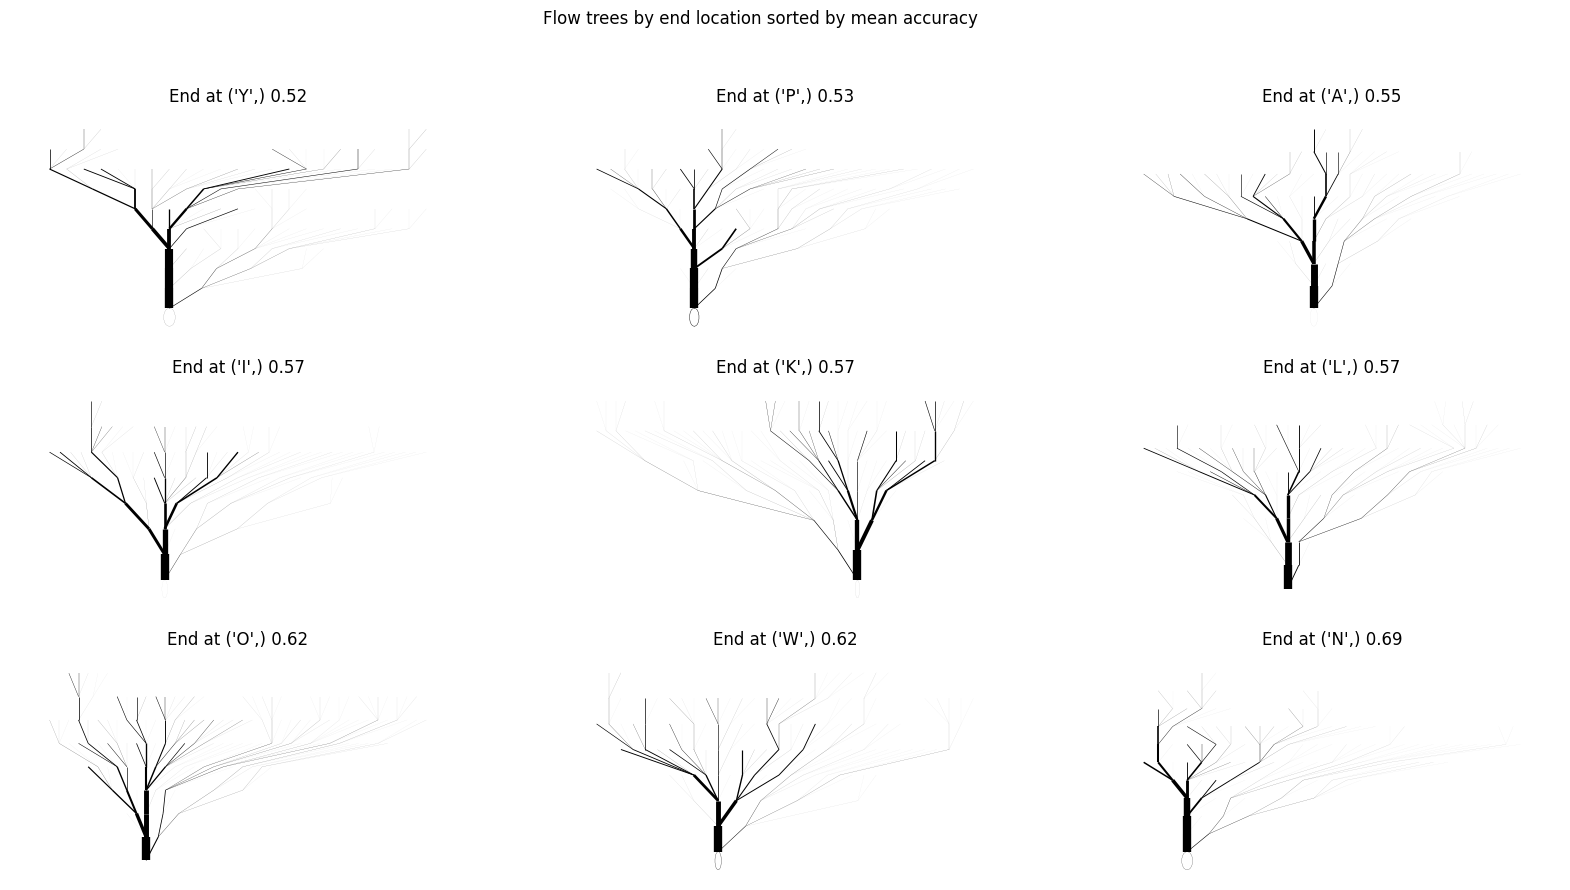

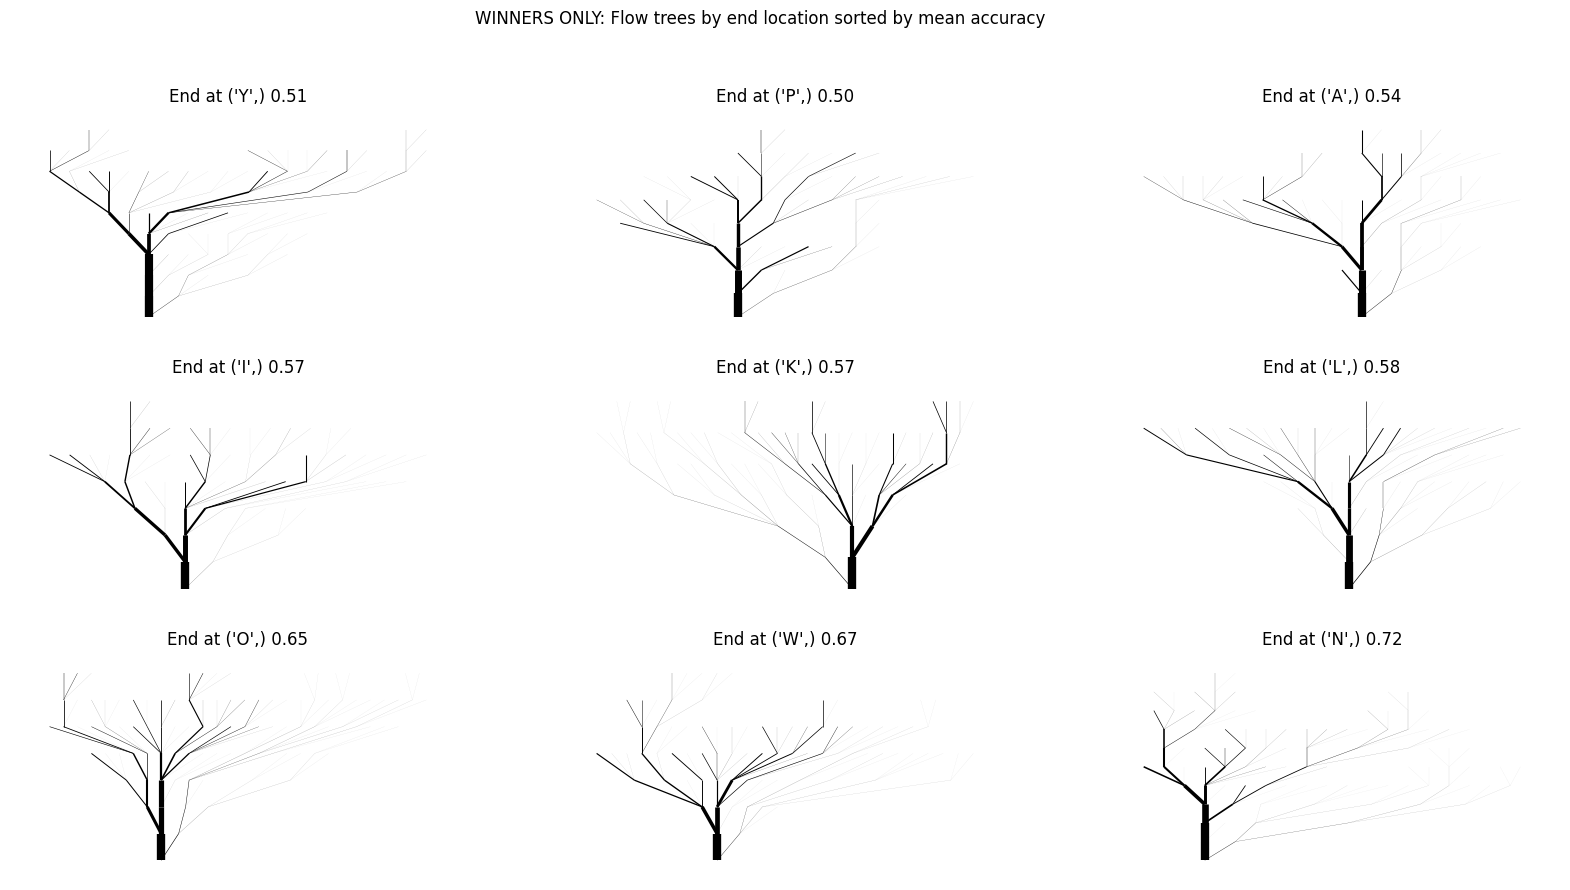

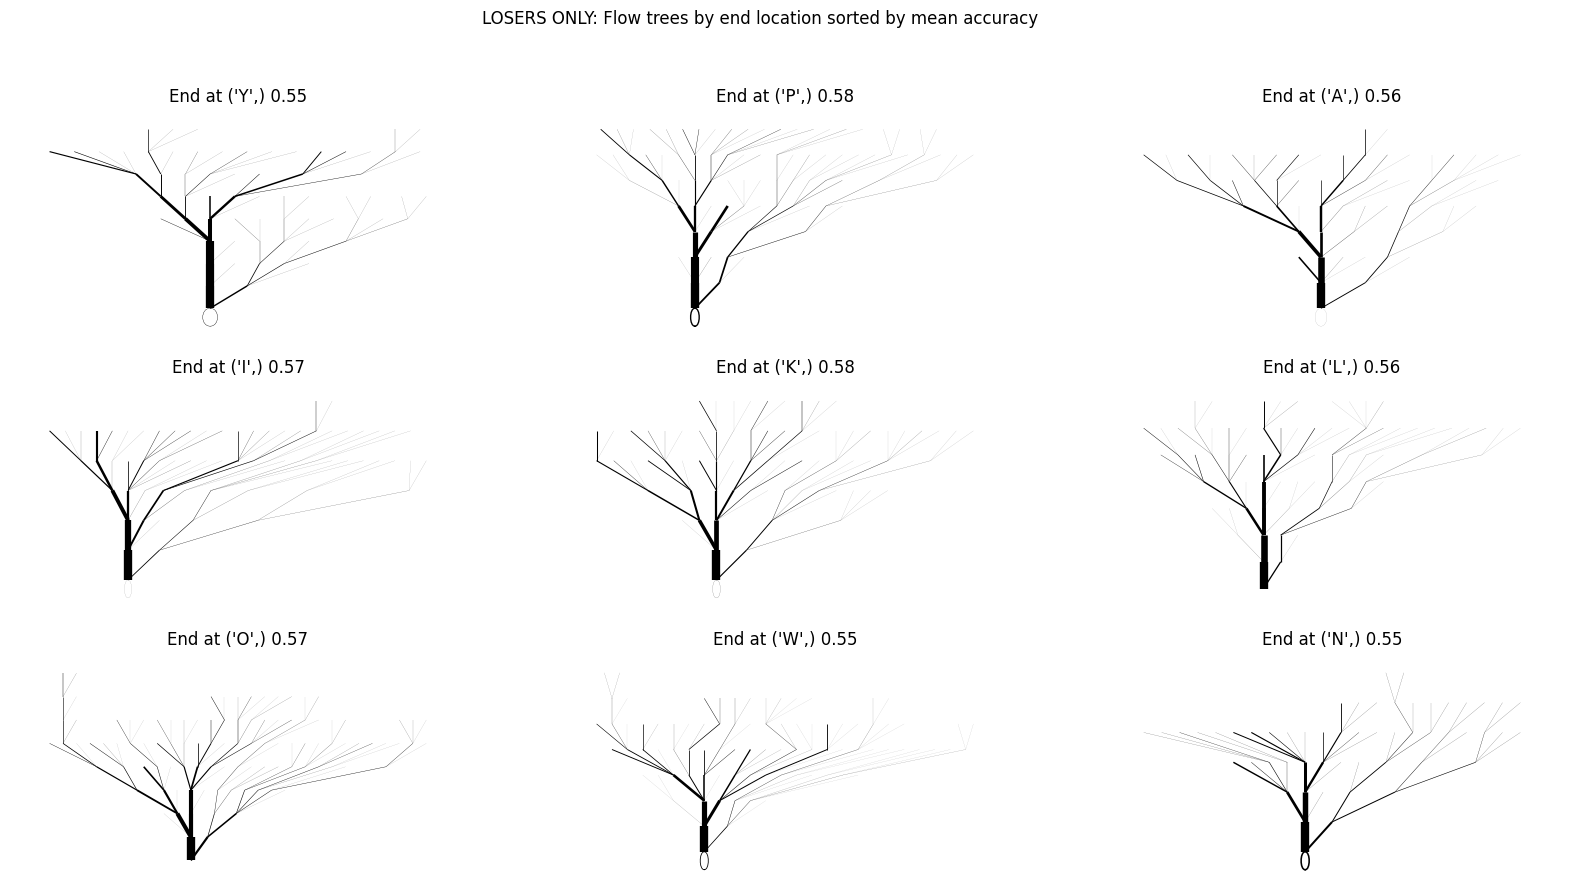

In [7]:
# Plot all trajectories
end_accs = [v[1] for v in end_tree_dict.values()]
end_graphs = [v[0] for v in end_tree_dict.values()]
end_nodes = list(end_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
sorted_order = [x for x in sorted(range(len(end_accs)), key=lambda x: end_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_nodes[tree_index]} {end_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("Flow trees by end location sorted by mean accuracy")
fig.savefig("figures/end_flow_trees_by_acc.png")
plt.show()

# Plot winners
end_winner_accs = [v[1] for v in end_winner_dict.values()]
end_winner_graphs = [v[0] for v in end_winner_dict.values()]
end_winner_nodes = list(end_winner_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(end_winner_accs)), key=lambda x: end_winner_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_winner_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_winner_nodes[tree_index]} {end_winner_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("WINNERS ONLY: Flow trees by end location sorted by mean accuracy") 
fig.savefig("figures/end_flow_trees_by_acc-winners.png")
plt.show()

# Plot losers
end_loser_accs = [v[1] for v in end_loser_dict.values()]
end_loser_graphs = [v[0] for v in end_loser_dict.values()]
end_loser_nodes = list(end_loser_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(end_loser_accs)), key=lambda x: end_loser_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_loser_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_loser_nodes[tree_index]} {end_loser_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("LOSERS ONLY: Flow trees by end location sorted by mean accuracy")
fig.savefig("figures/end_flow_trees_by_acc-losers.png")
plt.show()


# canyou gather people's intention from here? like look at subtrees and cluster???
# real human movement

## 3b. Generate bootstrapped trees

In [8]:
# Create empty DataFrame to store all tree information
tree_df = pd.DataFrame(columns=[
    'node_type',      # 'start' or 'end'
    'node',           # the actual node label
    'trajectory_type', # 'all', 'winner', or 'loser'
    'mean_accuracy',   # mean accuracy for this group
    'trees'           # list of bootstrapped trees
])
ttt = []
# Function to generate bootstrapped trees
def generate_bootstrap_trees(group, k_fold=20, sample_frac=0.7, reverse_trajs=False):
    trees = []
    for _ in range(k_fold):
        sampled_group = group.sample(frac=sample_frac)
        # Randomly select 58 samples if group is larger than that
        if len(sampled_group) > 58:
            sampled_group = sampled_group.sample(n=58)
        trajs = generate_trajs_from_df(sampled_group)
        if reverse_trajs:
            trajs = [list(reversed(t)) for t in trajs]
        ttt.append(len(trajs))
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
    return trees

# Generate trees for start nodes
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['accuracy']]),
    ('loser', test_df[~test_df['accuracy']])
]:
    for start_node, group in df_subset.groupby(['StartAt']):
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['start'] * len(trees),
            'node': [start_node] * len(trees), 
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

# Generate trees for end nodes
test_df['ending_node'] = test_df['paths'].apply(lambda x: x[-1])
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['ending_node'] == test_df['EndAt']]),
    ('loser', test_df[test_df['ending_node'] != test_df['EndAt']])
]:
    for end_node, group in df_subset.groupby(['ending_node']):
        if end_node[0] not in OBJECTS:
            continue
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group, reverse_trajs=True)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['end'] * len(trees),
            'node': [end_node] * len(trees),
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

print(np.mean(ttt))
print(max(ttt), min(ttt))

58.0
58 58


In [9]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    'node',           # the actual node label
    'trees'           # list of bootstrapped trees
])

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]

traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

k_fold = 20
for node in traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 20:
            sampled_indices = np.random.choice(len(sampled_trajs), size=20, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees
    })], ignore_index=True)
# all_tree_df

19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19
19


In [12]:
# Extract features for each tree
all_feature_names = None
all_features = []

for tree in all_tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    all_tree_df[f"feature_{name}"] = tree_features[:,i]



In [15]:
all_tree_df

,node,trees,feature_num_nodes,feature_depth,feature_diameter,feature_num_leaves,feature_avg_branching,feature_backbone_thickness
0,"(A,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",16.0,4.0,6.0,9.0,1.875000,11.333333
1,"(A,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",19.0,4.0,7.0,11.0,1.894737,6.750000
2,"(A,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",19.0,5.0,8.0,10.0,1.894737,9.600000
3,"(A,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",16.0,4.0,6.0,9.0,1.875000,9.000000
4,"(A,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",17.0,4.0,6.0,9.0,1.882353,10.250000
...,...,...,...,...,...,...,...,...
515,"(Z,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13)",14.0,4.0,6.0,8.0,1.857143,9.750000
516,"(Z,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",22.0,6.0,8.0,12.0,1.909091,10.200000
517,"(Z,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",24.0,6.0,9.0,14.0,1.916667,10.400000
518,"(Z,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",18.0,4.0,6.0,10.0,1.888889,12.000000


Mann-Whitney U test p-value: 0.2244
32579.5

Object nodes:
Mean diameter: 8.6629
Variance: 4.2530

Non-object nodes:
Mean diameter: 8.4470
Variance: 4.7070


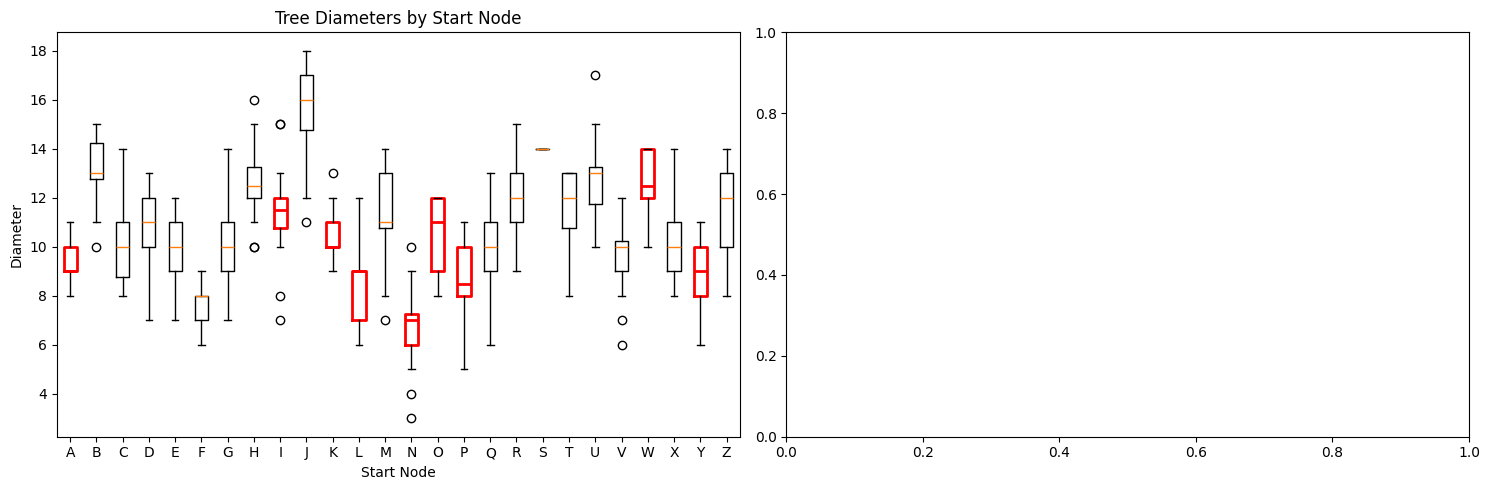

In [20]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for start nodes
all_nodes = all_tree_df['node'].unique()

# Split nodes into OBJECTS and non-OBJECTS
object_diameters = []
nonobject_diameters = []
for node in all_nodes:
    node_trees = all_tree_df[all_tree_df['node'] == node]
    diameters = node_trees['feature_backbone_thickness'] # feature_diameter, feature_avg_branching
    
    if str(node[0]) in OBJECTS:
        object_diameters.extend(diameters)
    else:
        nonobject_diameters.extend(diameters)

# Perform statistical test
from scipy import stats
stat, pval = stats.mannwhitneyu(object_diameters, nonobject_diameters)
print(f"Mann-Whitney U test p-value: {pval:.4f}")
print(stat)
# Print mean and variance for each group
print("\nObject nodes:")
print(f"Mean diameter: {np.mean(object_diameters):.4f}")
print(f"Variance: {np.var(object_diameters):.4f}")

print("\nNon-object nodes:") 
print(f"Mean diameter: {np.mean(nonobject_diameters):.4f}")
print(f"Variance: {np.var(nonobject_diameters):.4f}")


# Store diameters for plotting
all_diameters = []
node_labels = []
for node in all_nodes:
    node_trees = all_tree_df[all_tree_df['node'] == node]
    diameters = node_trees['feature_num_leaves'] # feature_diameter, feature_avg_branching
    all_diameters.append(diameters)
    node_labels.extend([str(node[0])] * len(diameters))

# Create box plot
labels = [str(n[0]) for n in traj_dict]
bp = ax1.boxplot(all_diameters, labels=labels)

# Color the boxes based on whether they are objects or not
for i, box in enumerate(bp['boxes']):
    node_label = labels[i]
    if node_label in OBJECTS:
        box.set(color='red', linewidth=2)
        bp['medians'][i].set(color='red', linewidth=2)
        # bp['whiskers'][i*2:i*2+2].set(color='red', linewidth=2)
        # bp['caps'][i*2:i*2+2].set(color='red', linewidth=2)
        # bp['fliers'][i].set(color='red')

ax1.set_title('Tree Diameters by Start Node')
ax1.set_xlabel('Start Node')
ax1.set_ylabel('Diameter')

plt.tight_layout()
plt.show()


In [ ]:
node_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
node_flow_tree_embedder.fit(np.array(all_tree_df["trees"]))

# Extract features for each tree
all_embeddings = []

# Get embeddings for each tree
all_tree_embeddings = node_flow_tree_embedder.infer(np.array(all_tree_df["trees"]))

# Add single column with full embedding vector
all_tree_df["embedding"] = [emb for emb in all_tree_embeddings]

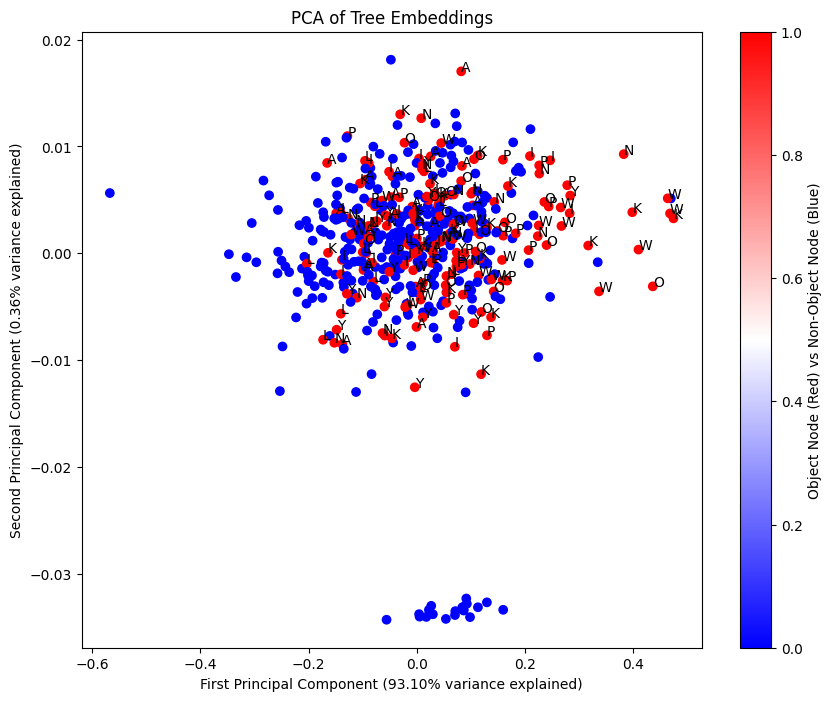


First Principal Component:
Mann-Whitney U test p-value: 1.999e-06
Significantly different

Means:
Object nodes PC1: 0.046
Non-object nodes PC1: -0.024
Object nodes PC2: 0.002
Non-object nodes PC2: -0.001

Standard Deviations:
Object nodes PC1: 0.135
Non-object nodes PC1: 0.123
Object nodes PC2: 0.005
Non-object nodes PC2: 0.009

Second Principal Component:
Mann-Whitney U test p-value: 5.613e-02
Not significantly different


In [ ]:
from sklearn.decomposition import PCA

# Convert embeddings to a matrix for PCA
embedding_matrix = np.array(all_tree_df["embedding"].tolist())

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embedding_matrix)

# Create scatter plot
plt.figure(figsize=(10,8))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], 
                     c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
                     cmap='bwr')

# Add labels for object nodes
for idx, row in all_tree_df.iterrows():
    if row["node"][0] in OBJECTS:
        plt.annotate(row["node"][0], (pca_result[idx,0], pca_result[idx,1]))

plt.title('PCA of Tree Embeddings')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
plt.colorbar(scatter, label='Object Node (Red) vs Non-Object Node (Blue)')
plt.show()

# Separate embeddings for object and non-object nodes
object_embeddings = pca_result[[n[0] in OBJECTS for n in all_tree_df["node"]]]
non_object_embeddings = pca_result[[n[0] not in OBJECTS for n in all_tree_df["node"]]]

# Perform statistical test (Mann-Whitney U test) on both principal components
from scipy import stats

# Test PC1
stat1, pval1 = stats.mannwhitneyu(object_embeddings[:,0], non_object_embeddings[:,0])
print("\nFirst Principal Component:")
print(f"Mann-Whitney U test p-value: {pval1:.3e}")
print("Significantly different" if pval1 < 0.05 else "Not significantly different")

# Calculate means and standard deviations for both groups
print("\nMeans:")
print(f"Object nodes PC1: {np.mean(object_embeddings[:,0]):.3f}")
print(f"Non-object nodes PC1: {np.mean(non_object_embeddings[:,0]):.3f}")
print(f"Object nodes PC2: {np.mean(object_embeddings[:,1]):.3f}") 
print(f"Non-object nodes PC2: {np.mean(non_object_embeddings[:,1]):.3f}")

print("\nStandard Deviations:")
print(f"Object nodes PC1: {np.std(object_embeddings[:,0]):.3f}")
print(f"Non-object nodes PC1: {np.std(non_object_embeddings[:,0]):.3f}")
print(f"Object nodes PC2: {np.std(object_embeddings[:,1]):.3f}")
print(f"Non-object nodes PC2: {np.std(non_object_embeddings[:,1]):.3f}")


# Test PC2  
stat2, pval2 = stats.mannwhitneyu(object_embeddings[:,1], non_object_embeddings[:,1])
print("\nSecond Principal Component:")
print(f"Mann-Whitney U test p-value: {pval2:.3e}")
print("Significantly different" if pval2 < 0.05 else "Not significantly different")



## 4. Featurise / embed them

### Tree features

In [11]:

def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    feature_names = ['num_nodes', 'depth', 'diameter', 'num_leaves', 'avg_branching', 'backbone_thickness']
    features = np.array([
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ])
    
    return feature_names, features


# Extract features for each tree
all_feature_names = None
all_features = []

for tree in tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    tree_df[f"feature_{name}"] = tree_features[:,i]


### Tree embeddings

In [ ]:
node_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
node_flow_tree_embedder.fit(np.array(tree_df["trees"]))

# Extract features for each tree
all_embeddings = []

# Get embeddings for each tree
tree_embeddings = node_flow_tree_embedder.infer(np.array(tree_df["trees"]))

# Add single column with full embedding vector
tree_df["embedding"] = [emb for emb in tree_embeddings]

In [ ]:
# # Get all start node winner trees
# start_winners = tree_df[(tree_df['node_type'] == 'start') & (tree_df['trajectory_type'] == 'winner')]

# # Get trees for a specific end node
# node_trees = tree_df[tree_df['node'] == ('A',)]

# # Sort by accuracy
# sorted_trees = tree_df.sort_values('mean_accuracy', ascending=False)


## 5. Cluster them

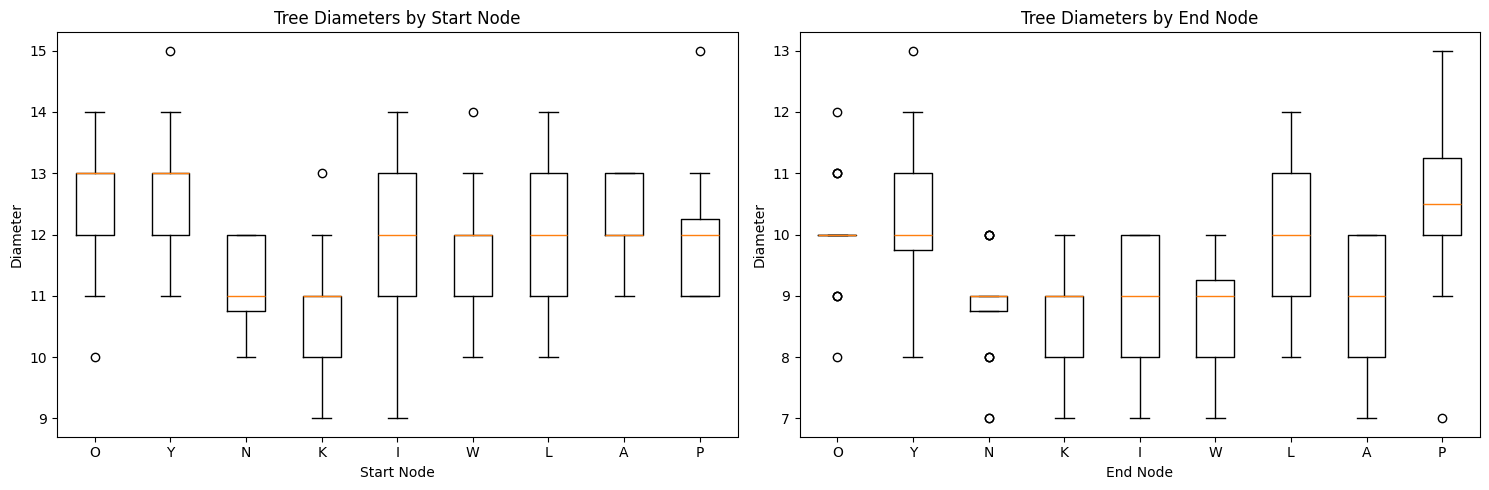

In [ ]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for start nodes
start_trees = tree_df[(tree_df['node_type'] == 'start') & (tree_df["trajectory_type"] == "all")]
start_nodes = start_trees['node'].unique()

start_diameters = []
start_node_labels = []
for node in OBJECTS:
    node = (node,)
    node_trees = start_trees[start_trees['node'] == node]
    diameters = node_trees['feature_diameter']
    start_diameters.append(diameters)
    start_node_labels.extend([str(node[0])] * len(diameters))

ax1.boxplot(start_diameters, labels=[str(n[0]) for n in OBJECTS])
ax1.set_title('Tree Diameters by Start Node')
ax1.set_xlabel('Start Node')
ax1.set_ylabel('Diameter')

# Plot for end nodes 
end_trees = tree_df[(tree_df['node_type'] == 'end') & (tree_df["trajectory_type"] == "all")]
end_nodes = end_trees['node'].unique()

end_diameters = []
end_node_labels = []
for node in OBJECTS:
    node = (node,)
    node_trees = end_trees[end_trees['node'] == node]
    diameters = node_trees['feature_diameter']
    end_diameters.append(diameters)
    end_node_labels.extend([str(node[0])] * len(diameters))

ax2.boxplot(end_diameters, labels=[str(n[0]) for n in OBJECTS])
ax2.set_title('Tree Diameters by End Node')
ax2.set_xlabel('End Node') 
ax2.set_ylabel('Diameter')

plt.tight_layout()
plt.show()
